In [1]:
import pandas as pd
import random

In [2]:
seed = 2025
n_stocks = 30

In [4]:
sp500 = pd.read_csv("sp500_constitutes.csv")
random.seed(seed)
selected = random.sample(sp500['Symbol'].tolist(), n_stocks)


In [5]:
print(selected)

['LEN', 'ADM', 'NDAQ', 'SNPS', 'IDXX', 'WM', 'CAT', 'KEY', 'MMM', 'FICO', 'XYL', 'FRT', 'LMT', 'COP', 'APH', 'FITB', 'FCX', 'AZO', 'AMZN', 'BBY', 'O', 'CFG', 'ZTS', 'GEV', 'AEP', 'MGM', 'ARE', 'LVS', 'JBL', 'ADI']


In [6]:
filtered_sp500 = sp500[sp500['Symbol'].isin(selected)]

In [9]:
columns_to_keep = filtered_sp500.columns[[0, 1, 2, 7]]
cleaned_df = filtered_sp500[columns_to_keep]


In [11]:
display(cleaned_df)

,Symbol,Security,GICS Sector,Founded
0,MMM,3M,Industrials,1902
14,ARE,Alexandria Real Estate Equities,Real Estate,1994
22,AMZN,Amazon,Consumer Discretionary,1994
25,AEP,American Electric Power,Utilities,1906
33,APH,Amphenol,Information Technology,1932
34,ADI,Analog Devices,Information Technology,1965
42,ADM,Archer Daniels Midland,Consumer Staples,1902
50,AZO,AutoZone,Consumer Discretionary,1979
60,BBY,Best Buy,Consumer Discretionary,1966
88,CAT,Caterpillar Inc.,Industrials,1925


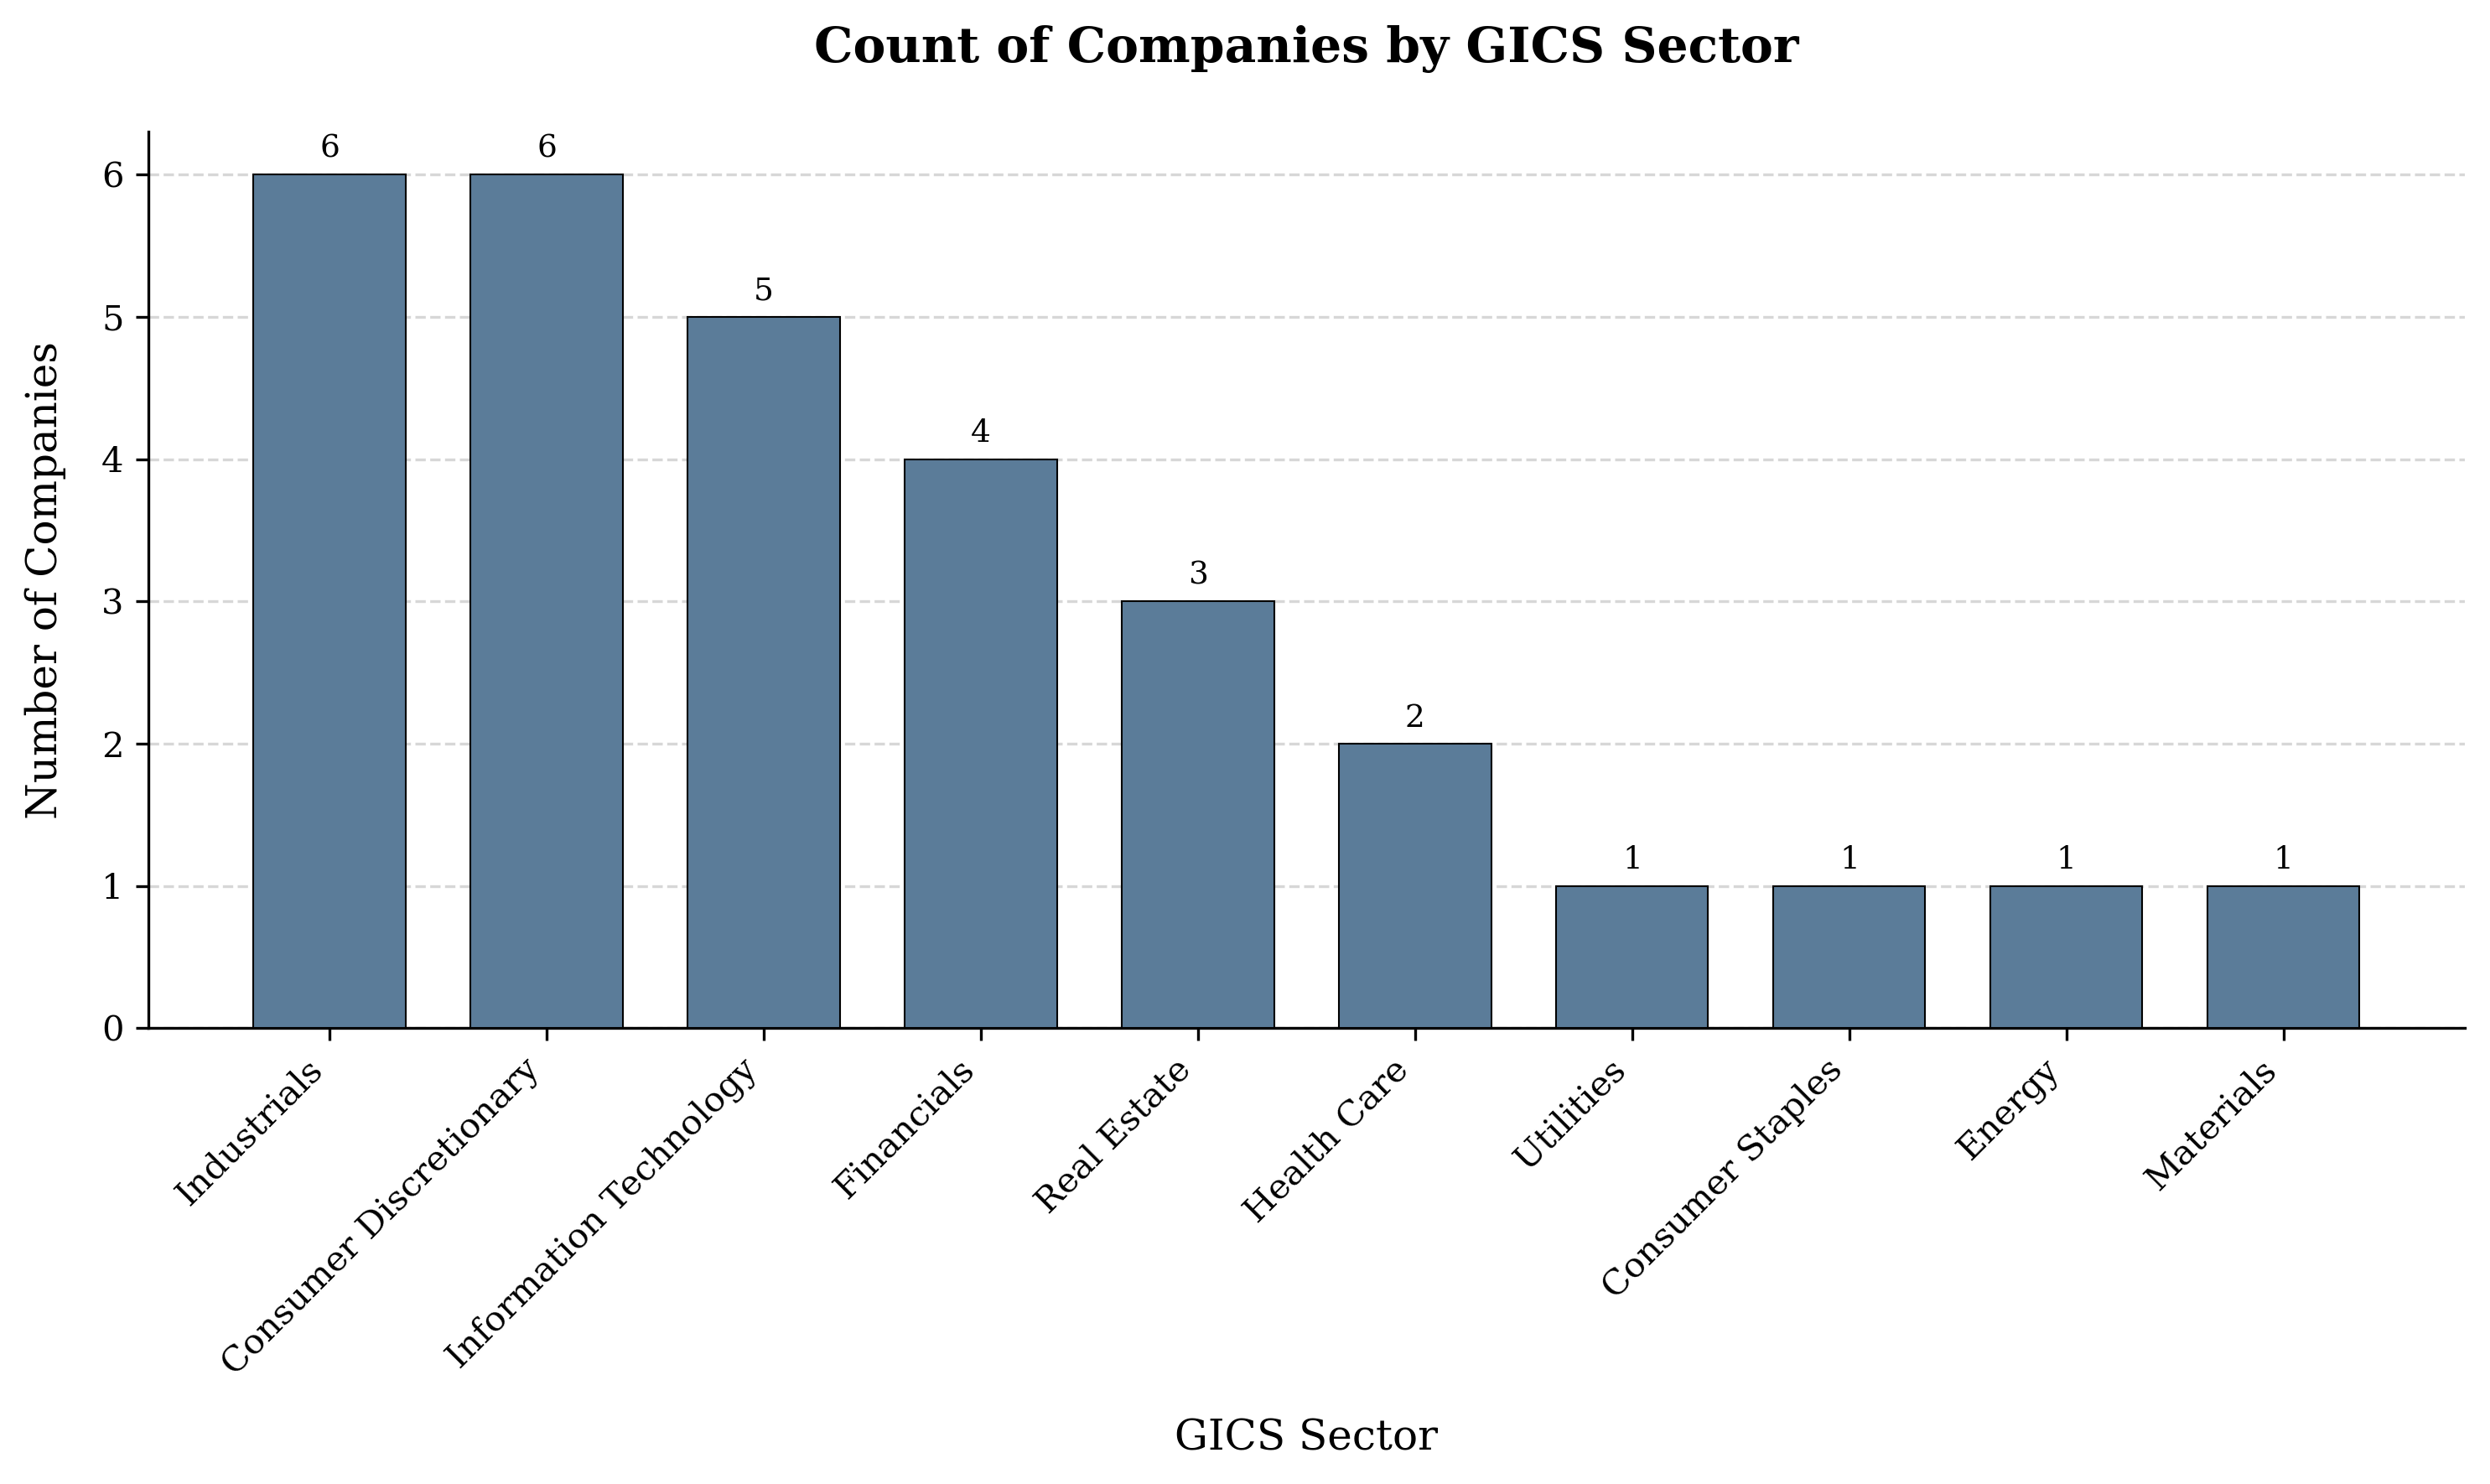

In [17]:
import matplotlib.pyplot as plt

sector_counts = cleaned_df['GICS Sector'].value_counts()

# 1. Setup global parameters for academic quality (Serif font, high DPI)
plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 300  # High resolution for print
})

# 2. Initialize Figure and Axis
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the bar plot
# zorder=3 ensures bars are drawn on top of the grid
bars = ax.bar(sector_counts.index, sector_counts.values, 
              color='#5B7C99', width=0.7, zorder=3, edgecolor='black', linewidth=0.5)

# 4. Styling and Formatting
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)  # Subtle grid lines
ax.spines['top'].set_visible(False)   # Remove top border
ax.spines['right'].set_visible(False) # Remove right border
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# 5. Labels and Title
ax.set_title('Count of Companies by GICS Sector', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('GICS Sector', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Companies', fontsize=12, labelpad=10)

# 6. Tick Formatting
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# 7. Add Data Labels (Annotations) on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sector_counts_plot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1920x1440 with 0 Axes>